# LAB n°2: Lemmatization, Tokenization and Language Modelling
- AMAR Wissam & Zakaria SOUALAH MOHAMMED (AI track)
- 16/09/2026

In [1]:
! python -m spacy download en_core_web_sm
! python -m spacy download fr_core_news_sm
! pip install nltk pandas scikit-learn

c:\Users\PC CABA DZ\Desktop\SACLABS\NLP_labs_Saclay\venv\Scripts\python.exe: No module named spacy
c:\Users\PC CABA DZ\Desktop\SACLABS\NLP_labs_Saclay\venv\Scripts\python.exe: No module named spacy



[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Exercise 1 : Lemmatization

In this exercise, the objective is to create your own lemmatizer for french language. We will test different lemmatization approaches : 
* Based on a dictionary
* Based on machine learning approach (you can use sklearn) or define your own architecture with pytorch
* With and without pos tag given as input

In all case you should compare your results and report performances of the proposed algorithm to [spacy](https://spacy.io/models/fr) lemmatizer (the different configuration).

You are free to use any machine-learning algorihtm/model, taking or not the context of sentences such as [LinearRegression](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LinearRegression.html) or training your own [RNN with pytorch](https://pytorch.org/docs/stable/generated/torch.nn.RNN.html). 
However you must always motivate your choices and compare results of the different configurations.

You will send the report to *thomas.gerald@universite-paris-saclay.fr* in PDF format named as following and the code (notebook with  output of the two exercises in a zip format) :


**report_[firstname]_[lastname].pdf**

The report for the two exercises must not exceed three pages !


## Dataset
To train or build your lemmatizer you have three files in *tabular separated values* format :
* [training-set.tsv](https://thomas-gerald.fr/TMC/resources/data/training-set.tsv) that you can use to train/build your dictionnary/model 
* [testing-set.tsv](https://thomas-gerald.fr/TMC/resources/data/testing-set.tsv) used to evaluate the different approaches
* [testing-gallica.tsv](https://thomas-gerald.fr/TMC/resources/data/testing-gallica.tsv) used as gold standard to evaluate performances [github (in french)](https://github.com/Gallicorpora/Lemmatisation)

In our case we have two possibilities for a lemma:
* (a) A sequence of characters, meaning that "to rule" an "a rule" are the same lemma
* (b) A sequence of characters, meaning that "to rule" represent the verb, a tuple ("rule", "V") while "a rule" is represented by the tuple ("rule", "N") 
In the (a) case the size of the vocabulary (output) will be 
## Spacy :

Below a small example using spacy lemmatization
```python
import spacy
nlp = spacy.load("en_core_web_sm")
text_a = "He is thirty years old"
text_b = "We still are champions"
print(f'Lemmatization A : {[(w.lemma_, w.pos_) for w in nlp(text_a)]}')
print(f'Lemmatization B : {[(w.lemma_, w.pos_) for w in nlp(text_b)]}')
```

### Inspecting ana Exploring the data


In [2]:
import pandas as pd
train_file = "corpus_data/training-set.tsv"
training_df=pd.read_csv(train_file, sep='\t', names=["token", "lemma", "pos"])
training_df.head(10)
print(f"We have {len(training_df)} training examples.")

We have 261389 training examples.


In the training corpus we have roughly 26k tokens and their lemmas

In [3]:
present_pos = training_df["pos"].tolist()
print(set(present_pos))
print(f"We have {len(set(present_pos))} different POS tags in the training set.")

{'ET', 'I', 'A', 'V', 'CL', 'C', 'D', 'P+D', nan, 'ADV', 'PRO', 'PREF', 'P+PRO', 'PONCT', 'P', 'N'}
We have 16 different POS tags in the training set.


In [4]:
C_pos = training_df[training_df['pos'] == 'C']
print(C_pos)
# -> We understand that C refers to Conjonction

            token      lemma pos
5             qu'        que   C
30           mais       mais   C
48            que        que   C
53      alors_que  alors_que   C
62             et         et   C
...           ...        ...  ..
261178         et         et   C
261244       soit       soit   C
261288         ou         ou   C
261304       puis       puis   C
261365         et         et   C

[8137 rows x 3 columns]


| Tag       | Catégorie grammaticale    | Explication                                                             | Exemple                               |
| --------- | ------------------------- | ----------------------------------------------------------------------- | ------------------------------------- |
| **N**     | Nom                       | Désigne une personne, un objet, un lieu, une idée, etc.                 | *maison, étudiant, liberté*           |
| **V**     | Verbe                     | Exprime une action, un état ou un événement.                            | *manger, être, courir*                |
| **A**     | Adjectif                  | Qualifie ou décrit un nom.                                              | *grand, intelligent, rouge*           |
| **ADV**   | Adverbe                   | Modifie un verbe, un adjectif ou un autre adverbe.                      | *rapidement, très, souvent*           |
| **D**     | Déterminant               | Introduit et précise un nom.                                            | *le, une, cette, mon*                 |
| **PRO**   | Pronom                    | Remplace un nom ou un groupe nominal.                                   | *il, elle, nous, quelqu’un*           |
| **P**     | Préposition               | Introduit un complément et exprime une relation.                        | *à, de, dans, avec*                   |
| **C**     | Conjonction               | Relie des mots, groupes de mots ou propositions.                        | *et, mais, parce que*                 |
| **ET**    | Élément de coordination   | Relie généralement deux éléments de même fonction, notamment avec *et*. | *Paul **et** Marie*                   |
| **CL**    | Clitique                  | Élément grammatical lié au verbe, souvent un pronom faible.             | *je **le** vois, **me** parle*        |
| **I**     | Interjection              | Exprime une émotion, une réaction ou une exclamation.                   | *ah, oh, bravo*                       |
| **PONCT** | Ponctuation               | Marque la structure et les limites des phrases.                         | *., ,, ?, !*                          |
| **PREF**  | Préfixe                   | Élément placé au début d’un mot pour modifier son sens.                 | *re-* dans *refaire*                  |
| **P+D**   | Préposition + déterminant | Fusion d’une préposition et d’un déterminant.                           | *au* = **à + le**, *du* = **de + le** |
| **P+PRO** | Préposition + pronom      | Combinaison ou contraction d’une préposition et d’un pronom.            | Selon les conventions du corpus       |
| **nan**   | Annotation manquante      | Valeur absente ou non renseignée dans le corpus.                        | *NaN*                                 |


In [5]:

w_vocabulary = {'unknow_word'}
l_vocabulary = set()
lp_vocabulary = set()

with open(train_file, 'r')  as f:
    for line in f:
        try: 
            word, lemma, pos = line.split()
            w_vocabulary.add(word)
            l_vocabulary.add(lemma)
            lp_vocabulary.add((lemma, pos))
        except: 
            pass

print(f'The input vocabulary contains : {len(w_vocabulary)} words' )
print(f'The number of str lemma is :  {len(l_vocabulary)}')
print(f'The number of lemma (considering PoS) is :  {len(lp_vocabulary)}')

The input vocabulary contains : 22945 words
The number of str lemma is :  14981
The number of lemma (considering PoS) is :  15920


In [6]:
import pandas as pd

train_path = "corpus_data/training-set.tsv"
test_path = "corpus_data/testing-set.tsv"
gallica_path = "corpus_data/testing-gallica.tsv"

train_df = pd.read_csv(train_path, sep="\t")
test_df = pd.read_csv(test_path, sep="\t")
gallica_df = pd.read_csv(gallica_path, sep="\t")

print("Training:", train_df.shape)
print("Testing:", test_df.shape)
print("Gallica:", gallica_df.shape)

print(train_df.head())
print(train_df.columns.tolist())
print(train_df.dtypes)

Training: (261388, 3)
Testing: (16693, 3)
Gallica: (2841, 4)
  Certes certes    ADV
0      ,      ,  PONCT
1   rien   rien    PRO
2     ne     ne    ADV
3    dit   dire      V
4    qu'    que      C
['Certes', 'certes', 'ADV']
Certes    object
certes    object
ADV       object
dtype: object


In [7]:
!pip install matplotlib


[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


pos
N        67970
D        37767
P        34823
PONCT    31049
V        28795
A        18553
ADV      12116
C         8137
P+D       7595
CL        5779
PRO       4330
NaN       3440
ET         785
PREF       177
P+PRO       40
I           33
Name: count, dtype: int64


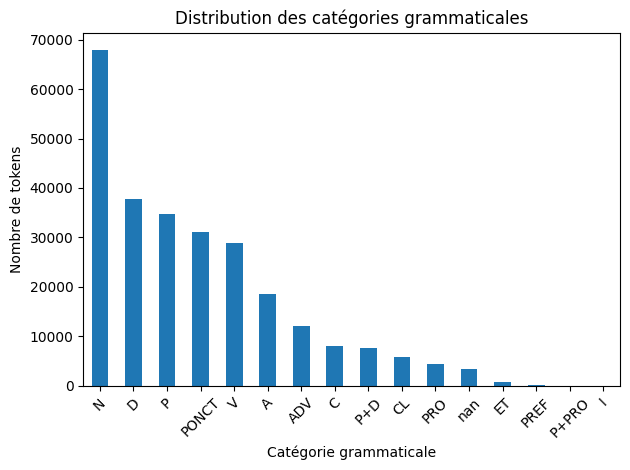

In [8]:
import matplotlib.pyplot as plt

pos_counts = training_df["pos"].value_counts(dropna=False)

print(pos_counts)

pos_counts.plot(kind="bar")
plt.title("Distribution des catégories grammaticales")
plt.xlabel("Catégorie grammaticale")
plt.ylabel("Nombre de tokens")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [9]:
# we define the evaluation metrics fro the appraoches
def evaluate(y_true, y_pred):
    correct = sum(
        true == pred
        for true, pred in zip(y_true, y_pred)
    )

    total = len(y_true)

    return correct / total


def unknown_rate(words, dictionary):
    unknown = sum(word not in dictionary for word in words)
    return unknown / len(words)

# Approach 1 : Dictionaty Based
It should map every word to its closest lemma

- word → most frequent lemma

In [10]:
from collections import defaultdict, Counter

import pandas as pd

columns = ["form", "lemma", "pos"]

train = pd.read_csv(
    "corpus_data/training-set.tsv",
    sep="\t",
    header=None,
    names=columns
)

test = pd.read_csv(
    "corpus_data/testing-set.tsv",
    sep="\t",
    header=None,
    names=columns
)

gallica = pd.read_csv(
    "corpus_data/testing-gallica.tsv",
    sep="\t",
    header=0
)
gallica = gallica.rename(columns={"POS": "pos"})

print(train.head())
print(test.head())
print(gallica.head())

     form   lemma    pos
0  Certes  certes    ADV
1       ,       ,  PONCT
2    rien    rien    PRO
3      ne      ne    ADV
4     dit    dire      V
              form            lemma    pos
0              Non              non    ADV
1        compensée        compenser      V
2    salarialement    salarialement    ADV
3                (                (  PONCT
4  le_plus_souvent  le_plus_souvent    ADV
      form     lemma     pos                               morph
0        S        il  PROper       PERS.=3|NOMB.=s|GENRE=n|CAS=r
1   ensuyt  ensuivre  VERcjg  MODE=ind|TEMPS=pst|PERS.=3|NOMB.=s
2       la        le  DETdef                     NOMB.=s|GENRE=f
3     tres      très  ADVgen                         MORPH=empty
4  louable   louable  ADJqua                     NOMB.=s|GENRE=f


In [11]:
print("TRAIN:", train.shape)
print("TEST:", test.shape)
print("GALLICA:", gallica.shape)

print("\nMissing values:")
print(train.isna().sum())
print(test.isna().sum())
print(gallica.isna().sum())

print("\nNumber of POS tags:")
print(train["pos"].nunique())

print("\nPOS tags:")
print(train["pos"].value_counts())

TRAIN: (261389, 3)
TEST: (16694, 3)
GALLICA: (2841, 4)

Missing values:
form        0
lemma       0
pos      3440
dtype: int64
form       0
lemma      0
pos      317
dtype: int64
form     0
lemma    0
pos      0
morph    0
dtype: int64

Number of POS tags:
15

POS tags:
pos
N        67970
D        37767
P        34823
PONCT    31049
V        28795
A        18553
ADV      12116
C         8137
P+D       7595
CL        5779
PRO       4330
ET         785
PREF       177
P+PRO       40
I           33
Name: count, dtype: int64


In [12]:
train_vocab = set(train["form"])

test_oov = ~test["form"].isin(train_vocab)
gallica_oov = ~gallica["form"].isin(train_vocab)

print(f"Test OOV: {test_oov.mean():.2%}")
print(f"Gallica OOV: {gallica_oov.mean():.2%}")

Test OOV: 6.03%
Gallica OOV: 46.29%


In [13]:
from collections import defaultdict, Counter

word_to_lemma = defaultdict(Counter)

for _, row in train.iterrows():
    word_to_lemma[row["form"]][row["lemma"]] += 1

dictionary_no_pos = {
    form: counts.most_common(1)[0][0]
    for form, counts in word_to_lemma.items()
}

In [14]:
from collections import defaultdict, Counter

def dictionary_lemmatize(form):
    return dictionary_no_pos.get(form, form)
word_to_lemma = defaultdict(Counter)

for _, row in train.iterrows():
    word_to_lemma[row["form"]][row["lemma"]] += 1

dictionary_no_pos = {
    form: counts.most_common(1)[0][0]
    for form, counts in word_to_lemma.items()
}
pred = test["form"].apply(dictionary_lemmatize)

accuracy = (pred == test["lemma"]).mean()

print(f"Dictionary accuracy: {accuracy:.4%}")

Dictionary accuracy: 94.3273%


In [15]:
word_pos_to_lemma = defaultdict(Counter)

for _, row in train.iterrows():
    key = (row["form"], row["pos"])
    word_pos_to_lemma[key][row["lemma"]] += 1

dictionary_pos = {
    key: counts.most_common(1)[0][0]
    for key, counts in word_pos_to_lemma.items()
}
def dictionary_lemmatize_pos(form, pos):
    return dictionary_pos.get((form, pos), form)
pred_pos = [
    dictionary_lemmatize_pos(form, pos)
    for form, pos in zip(test["form"], test["pos"])
]

accuracy_pos = (
    pd.Series(pred_pos).values == test["lemma"].values
).mean()

print(f"Dictionary + POS accuracy: {accuracy_pos:.4%}")

Dictionary + POS accuracy: 95.5074%


- Dictionary accuracy: 94.3273%
- Dictionary + POS accuracy: 95.5074%


In [16]:
ambiguity = (
    train.groupby("form")["lemma"]
    .nunique()
    .sort_values(ascending=False)
)

print("Forms with multiple possible lemmas:")
print(ambiguity[ambiguity > 1].head(20))
print(
    f"Number of ambiguous forms: "
    f"{(ambiguity > 1).sum()}"
)

Forms with multiple possible lemmas:
form
ministre       8
du             7
des            6
nous           6
de             5
d'             5
fait           5
vous           5
A              4
compte         4
elles          4
s'             4
va             4
démunis        3
D'             3
département    3
Est            3
de_l'          3
Qu'            3
au             3
Name: lemma, dtype: int64
Number of ambiguous forms: 879


In [17]:
for form in ambiguity[ambiguity > 1].head(10).index:
    print("\n", form)

    print(
        train[train["form"] == form][
            ["form", "lemma", "pos"]
        ].drop_duplicates()
    )


 ministre
            form                                              lemma pos
324     ministre                                           ministre   N
23857   ministre   ministre_de_l'industrie_et_du_commerce_extérieur   N
23874   ministre  ministre_du_commerce_international_et_de_l'ind...   N
23894   ministre             ministre_du_commerce_et_de_l'industrie   N
149964  ministre                              ministre_des_finances   N
158452  ministre                          ministre_de_l'agriculture   N
245997  ministre                                ministre_du_travail   N
255091  ministre                             ministre_de_l'économie   N

 du
       form         lemma  pos
20       du            de  P+D
144      du            du  P+D
1064     du            du    D
51682    du       du_coup  ADV
120412   du    à_cause_de    P
172871   du    au_sein_de    P
195372   du            un    D
235898   du  en_raison_de    P
256892   du            du    P

 des
       form         


| Method           |     Accuracy |
| ---------------- | -----------: |
| Dictionary       | **94.3273%** |
| Dictionary + POS | **95.5074%** |


In [18]:
# Compare the two predictions
comparison = pd.DataFrame({
    "form": test["form"],
    "gold_lemma": test["lemma"],
    "gold_pos": test["pos"],
    "dict_pred": pred,
    "dict_pos_pred": pred_pos
})

# Cases where dictionary fails but dictionary+POS succeeds
improved = comparison[
    (comparison["dict_pred"] != comparison["gold_lemma"]) &
    (comparison["dict_pos_pred"] == comparison["gold_lemma"])
]

print(f"Cases corrected by POS: {len(improved)}")
print(improved.head(30))

Cases corrected by POS: 224
             form   gold_lemma gold_pos   dict_pred dict_pos_pred
24             l'           il       CL          le            il
60        précise       précis        A    préciser        précis
80            des           un        D          de            un
108         donné        donné        A      donner         donné
170        défini       défini        A     définir        défini
172            De           un        D          de            un
681   développées    développé        A  développer     développé
798          fait         fait        N       faire          fait
891           des           un        D          de            un
1091       risque       risque        N     risquer        risque
1265  poursuivant  poursuivant        N  poursuivre   poursuivant
1269       oeuvre      oeuvrer        V      oeuvre       oeuvrer
1274         tous         tous      PRO        tout          tous
1341          des           un        D         

- Dictionary accuracy: 94.3273%
- Dictionary + POS accuracy: 95.5074%


# Second appraoch : ML based

In [ ]:
# from sklearn.feature_extraction.text import TfidfVectorizer

# vectorizer = TfidfVectorizer(
#     analyzer="char",
#     ngram_range=(3, 5),
#     min_df=3,
#     max_features=15000,
#     lowercase=False
# )

# X_train = vectorizer.fit_transform(train["form"])
# X_test = vectorizer.transform(test["form"])

# y_train = train["lemma"]
# y_test = test["lemma"]

# print("Training matrix:", X_train.shape)
# print("Testing matrix:", X_test.shape)

Training matrix: (261389, 15000)
Testing matrix: (16694, 15000)


In [41]:
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.linear_model import SGDClassifier

# Character-level representation
vectorizer = HashingVectorizer(
    analyzer="char",
    ngram_range=(2, 5),
    n_features=10000,
    lowercase=False,
    alternate_sign=False,
    norm="l2"
)

X_train = vectorizer.transform(train["form"])
X_test = vectorizer.transform(test["form"])

y_train = train["lemma"]
y_test = test["lemma"]

print("Training matrix:", X_train.shape)
print("Testing matrix:", X_test.shape)

Training matrix: (261389, 10000)
Testing matrix: (16694, 10000)


In [42]:
from sklearn.linear_model import SGDClassifier
from tqdm.auto import tqdm

model = SGDClassifier(
    loss="log_loss",
    tol=None,
    random_state=42,
    n_jobs=-1
)

classes = y_train.unique()

for epoch in tqdm(range(5), desc="Training epochs"):
    model.partial_fit(X_train, y_train, classes=classes)

print("Training completed!")

Training epochs:   0%|          | 0/5 [05:30<?, ?it/s]


KeyboardInterrupt: 

In [ ]:

ml_pred = model.predict(X_test)

ml_accuracy = (ml_pred == y_test).mean()

print(f"ML without POS accuracy: {ml_accuracy:.4%}")

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from tqdm.auto import tqdm

# Combine the surface form and POS tag
train_input_pos = (
    train["form"].fillna("").astype(str)
    + " POS_"
    + train["pos"].fillna("UNKNOWN").astype(str)
)

test_input_pos = (
    test["form"].fillna("").astype(str)
    + " POS_"
    + test["pos"].fillna("UNKNOWN").astype(str)
)

# Character-level features
vectorizer_pos = TfidfVectorizer(
    analyzer="char",
    ngram_range=(2, 5),
    min_df=3,
    max_features=15000,
    lowercase=False,
    sublinear_tf=True
)

X_train_pos = vectorizer_pos.fit_transform(train_input_pos)
X_test_pos = vectorizer_pos.transform(test_input_pos)

y_train = train["lemma"]
y_test = test["lemma"]

print("Training matrix:", X_train_pos.shape)
print("Testing matrix:", X_test_pos.shape)

In [ ]:
model_pos = SGDClassifier(
    loss="log_loss",
    tol=None,
    random_state=42,
    n_jobs=-1
)

classes = y_train.unique()

for epoch in tqdm(range(5), desc="Training POS-aware model"):
    model_pos.partial_fit(
        X_train_pos,
        y_train,
        classes=classes
    )

print("Training completed!")

In [ ]:
ml_pred_pos = model_pos.predict(X_test_pos)

ml_accuracy_pos = (
    ml_pred_pos == y_test.to_numpy()
).mean()

print(f"ML with POS accuracy: {ml_accuracy_pos:.4%}")

In [ ]:
print(f"ML without POS: {ml_accuracy:.4%}")
print(f"ML with POS:    {ml_accuracy_pos:.4%}")
print(f"Improvement:    {(ml_accuracy_pos - ml_accuracy) * 100:.2f} percentage points")